# Medical Insurance Forecast

## EDA 

In [2]:
import numpy as np 
import pandas as pd 

df = pd.read_csv("/kaggle/input/insurance/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Data Overview 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
print("shape of dataset" , df.shape)

shape of dataset (1338, 7)


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
print(df.duplicated().sum())

1


In [18]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


### Target Distribution

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


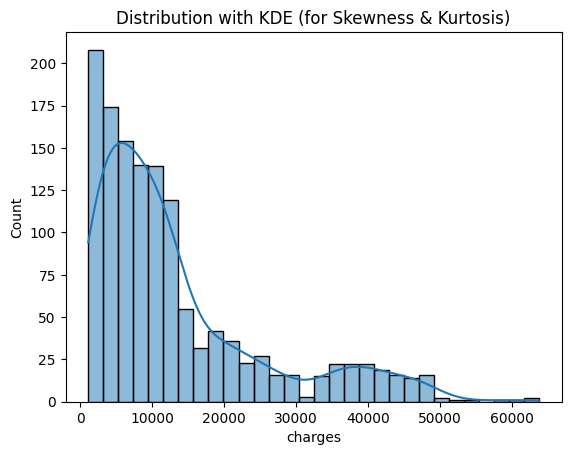

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde=True)
plt.title('Distribution with KDE (for Skewness & Kurtosis)')
plt.show()

In [26]:
print("Charges Skewness", df['charges'].skew())
print("Charges kurt", df['charges'].kurt())

Charges Skewness 1.5158796580240386
Charges kurt 1.6062986532967907


In [37]:
# Positively skewed,
# Most insurance charges are clustered at lower values
# A few customers have very high charges, pulling the mean to the right

# Leptokurtic Kurtosis,
# heavier tails and sharper peak than normal

<Axes: xlabel='charges'>

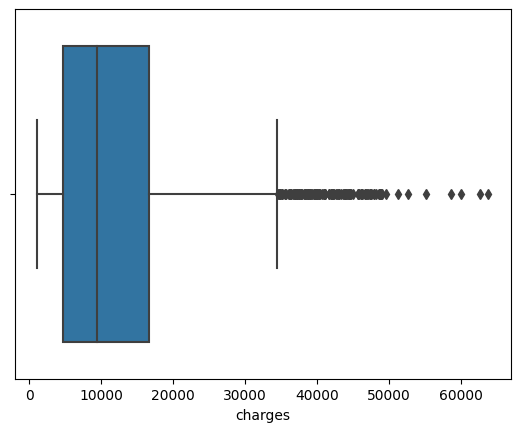

In [38]:
# outliers of target

sns.boxplot(x ='charges' , data=df)

### Feature Visualization

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


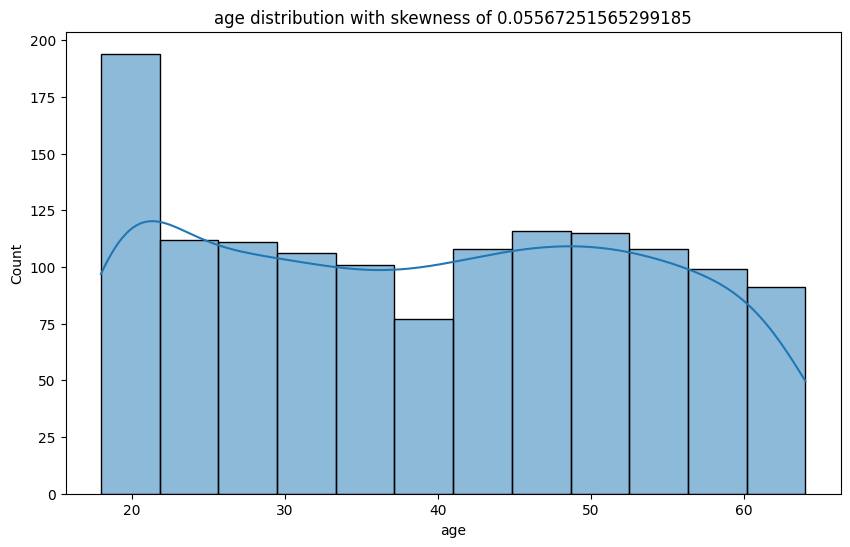

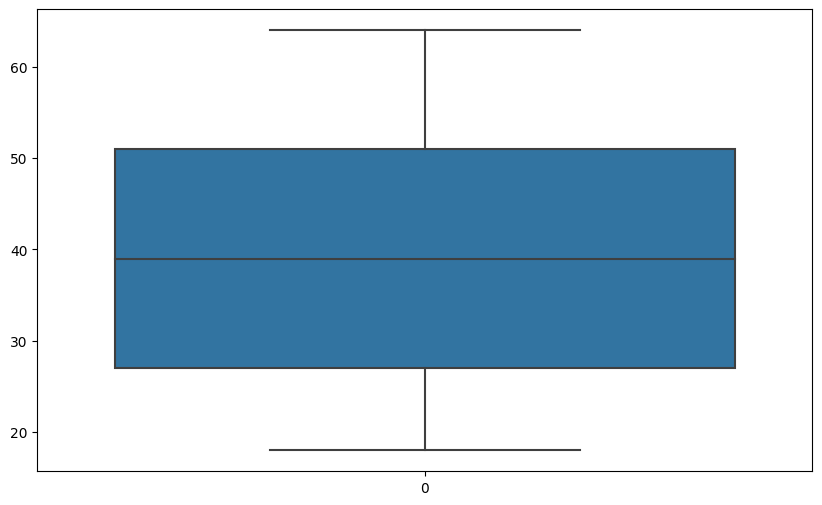

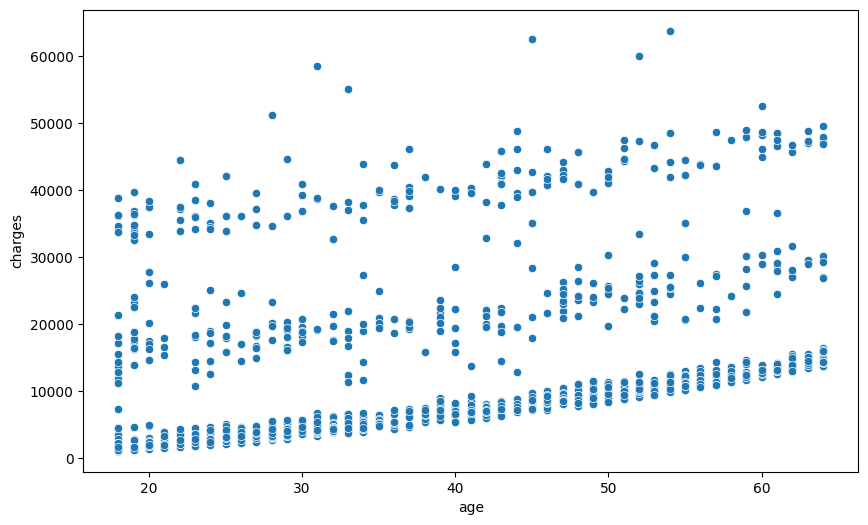

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


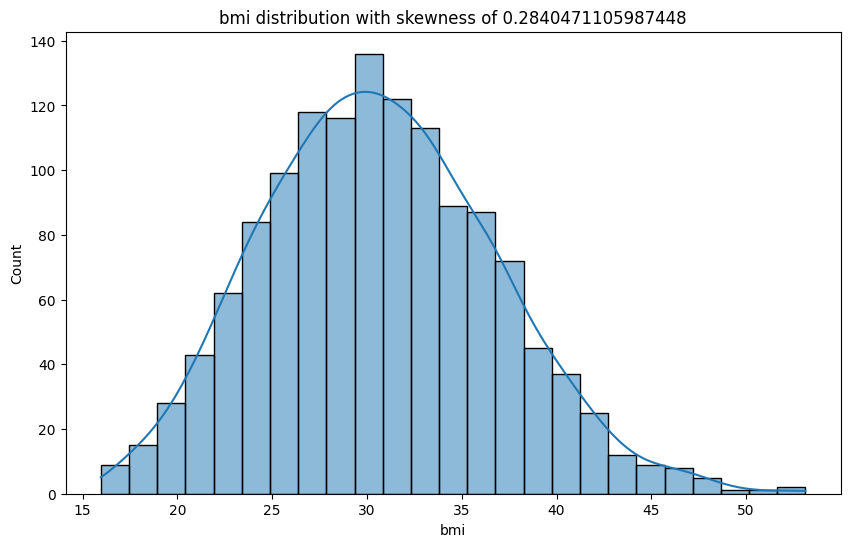

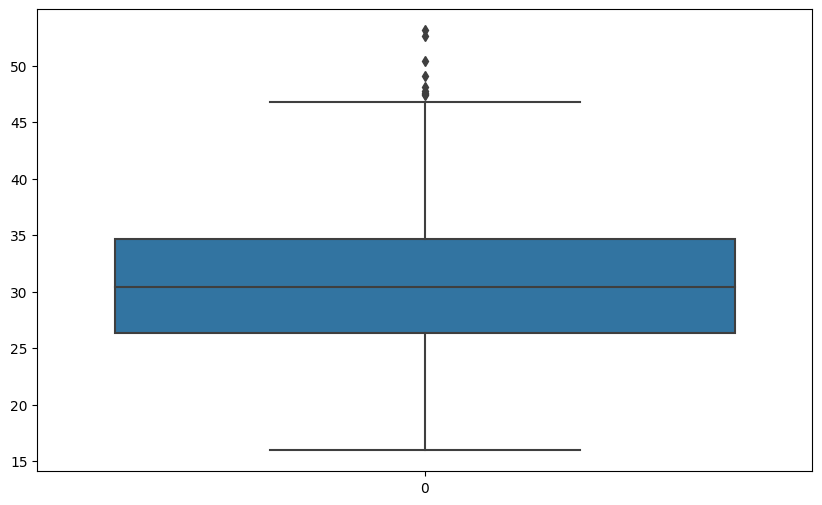

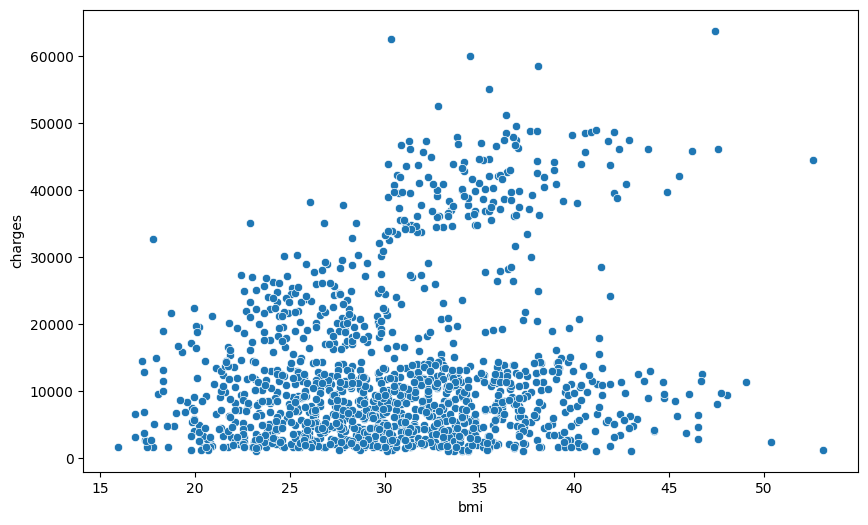

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


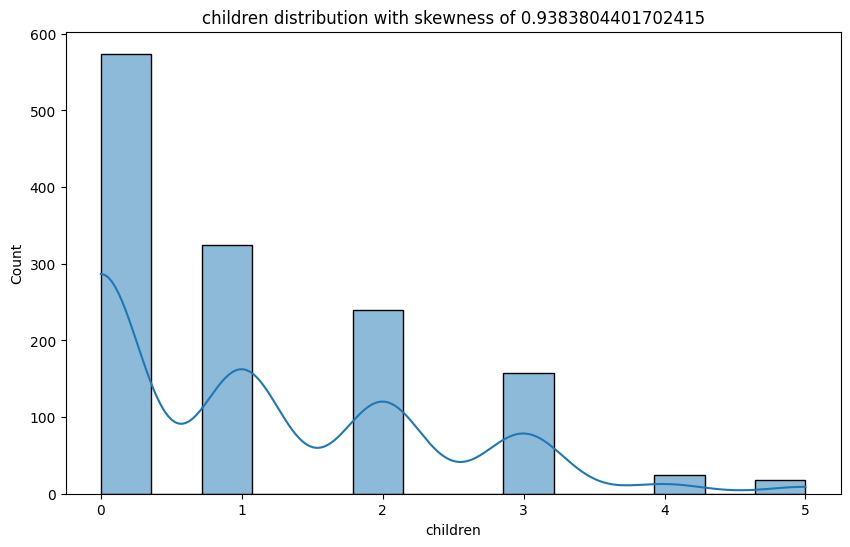

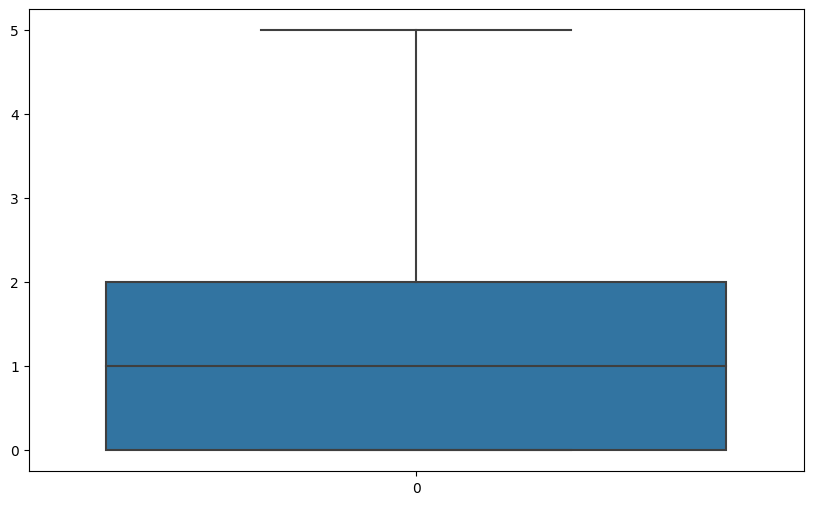

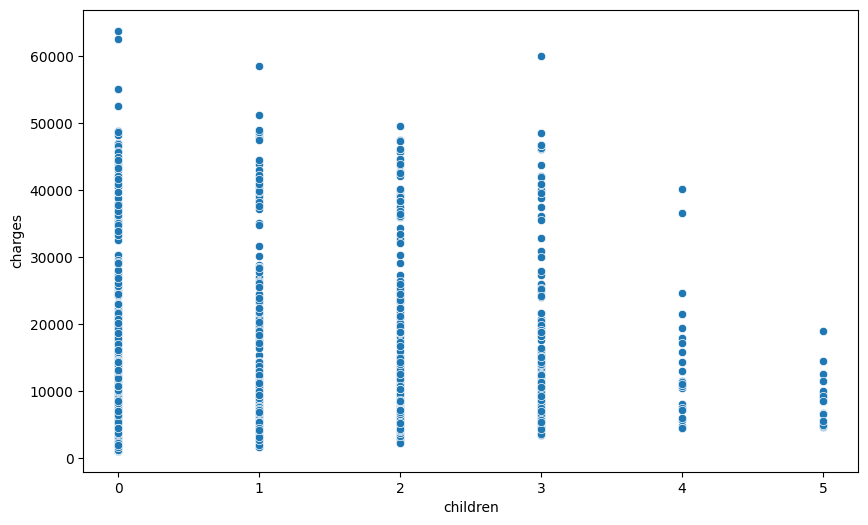

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


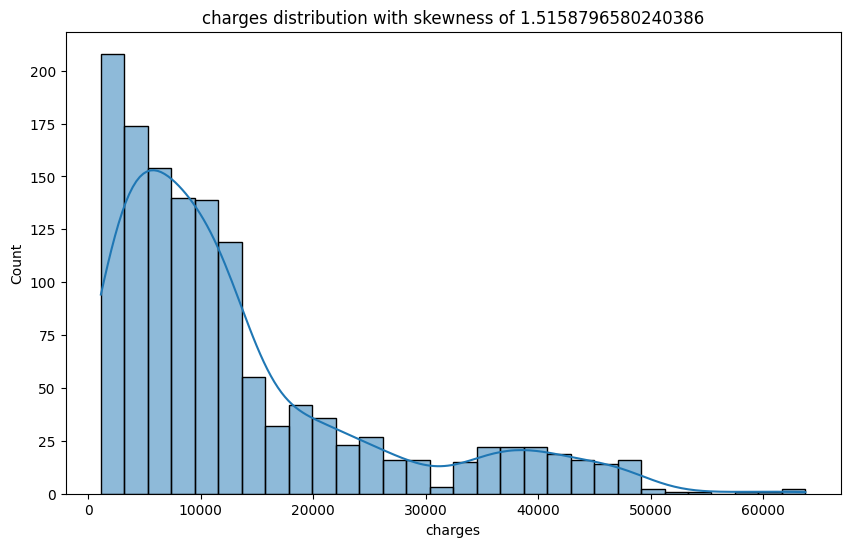

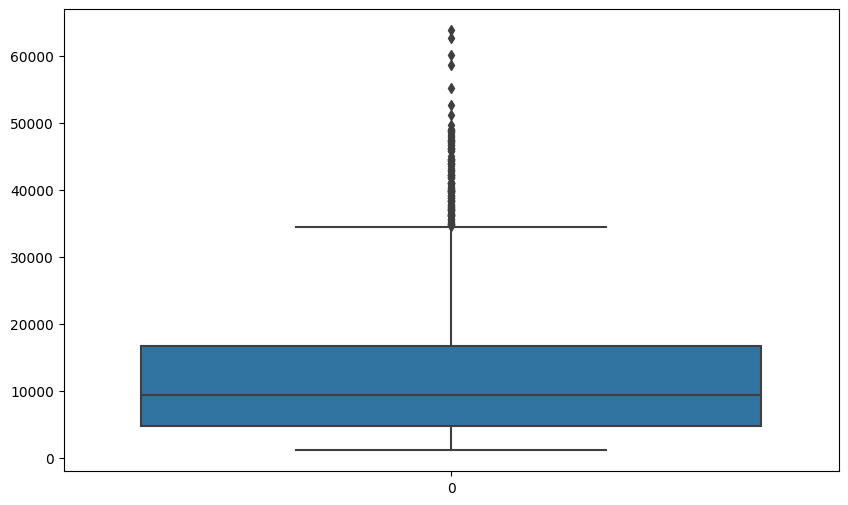

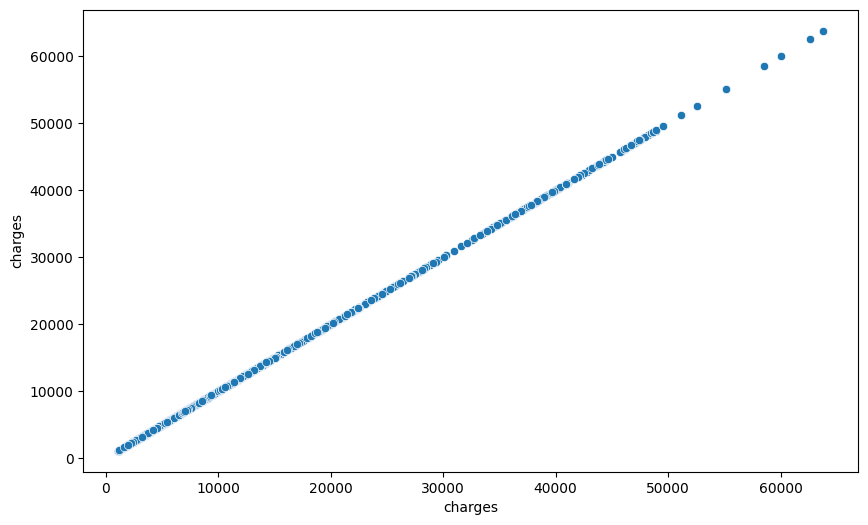

In [55]:
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()

for col in num_cols:
    plt.figure(figsize = (10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} distribution with skewness of {df[col].skew()}")
    plt.show()

    plt.figure(figsize = (10, 6))
    sns.boxplot(df[col])
    plt.show()

    plt.figure(figsize = (10, 6))
    sns.scatterplot(x=col, y='charges', data=df)
    plt.show()

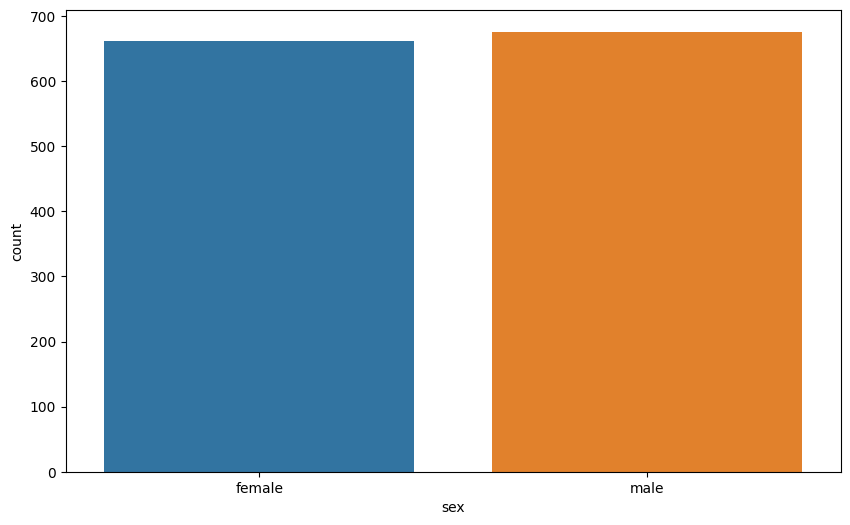

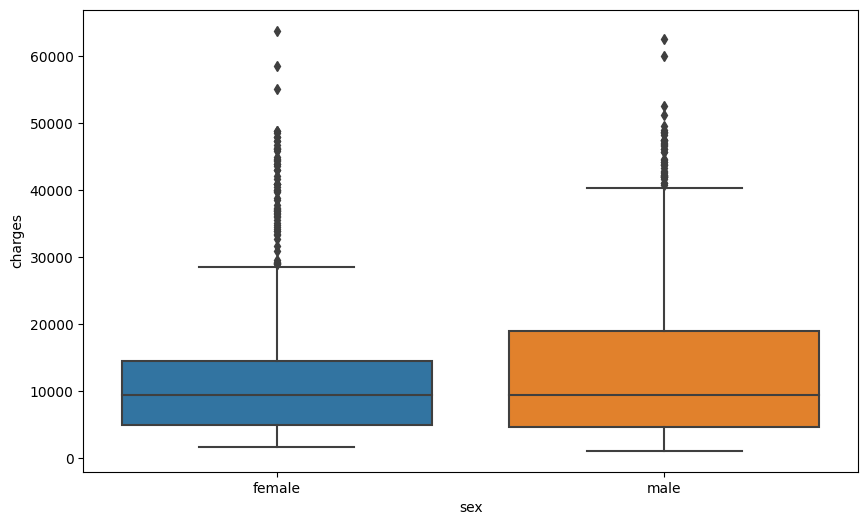

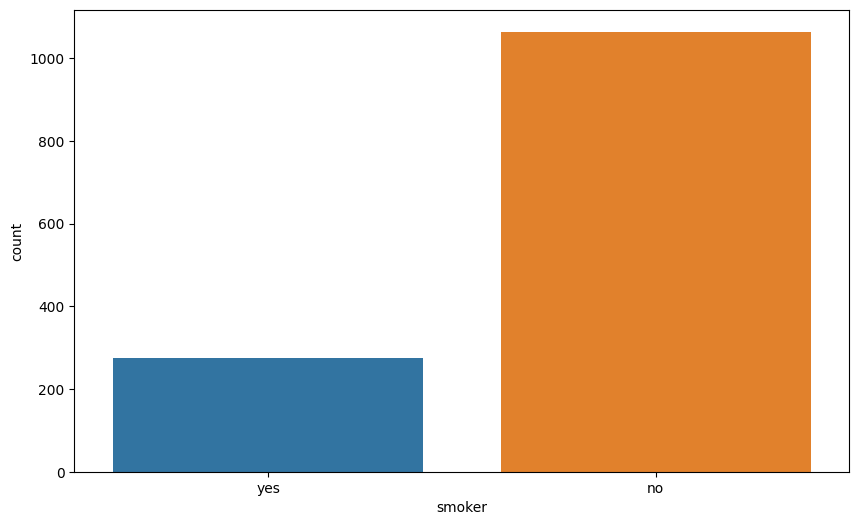

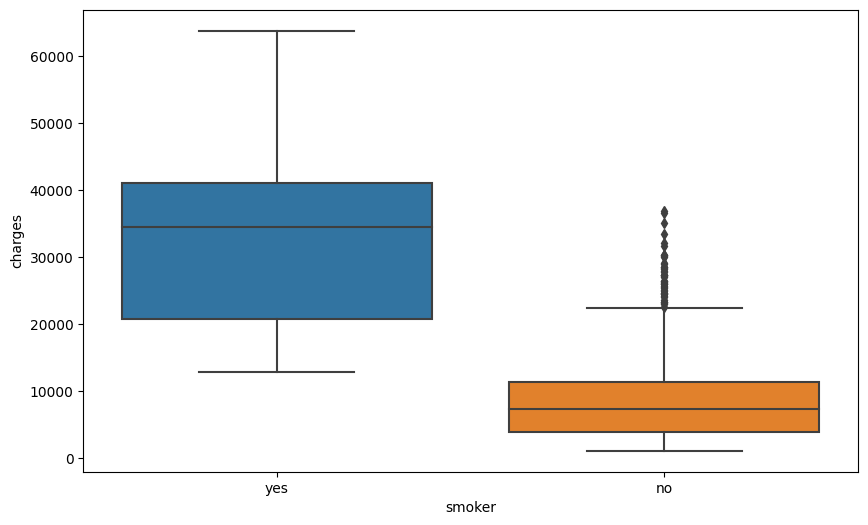

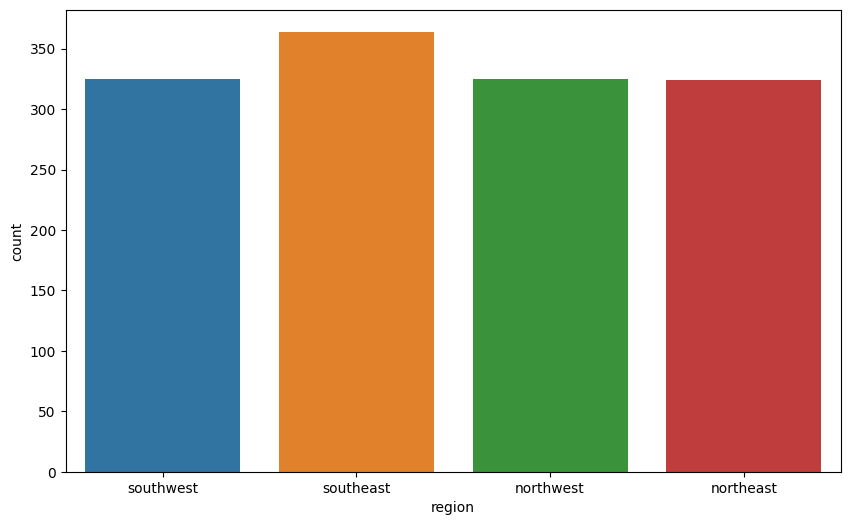

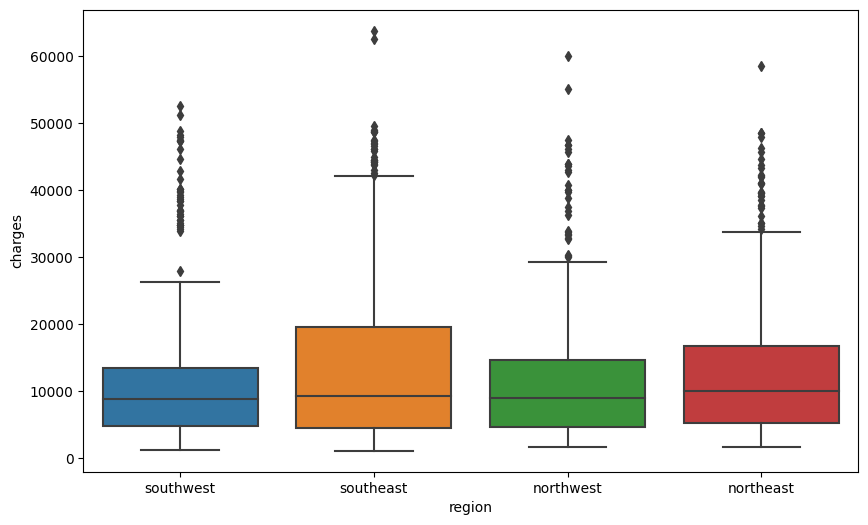

In [53]:
for col in cat_cols:
    plt.figure(figsize = (10, 6))
    sns.countplot(x = col, data=df)
    plt.show()

    plt.figure(figsize = (10, 6))
    sns.boxplot(x = col, y = 'charges',  data=df)
    plt.show()


### Target Mean Plot 

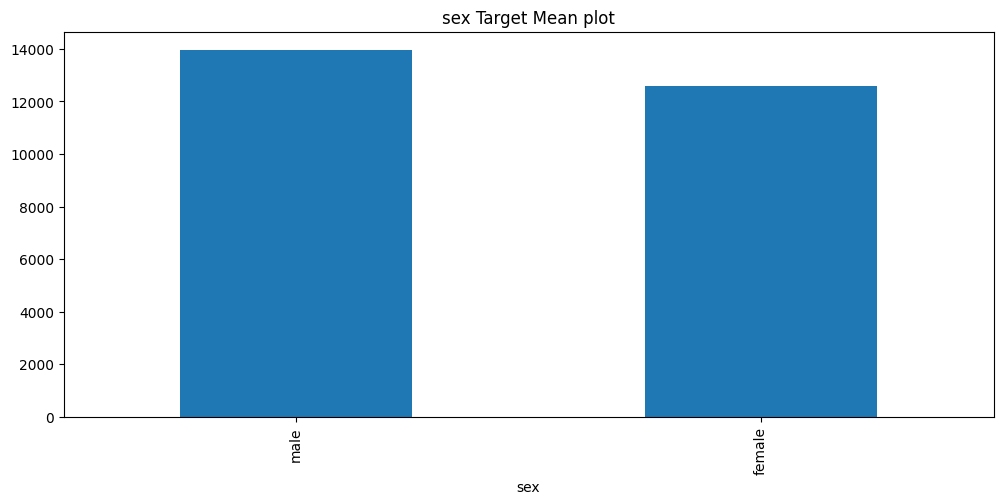

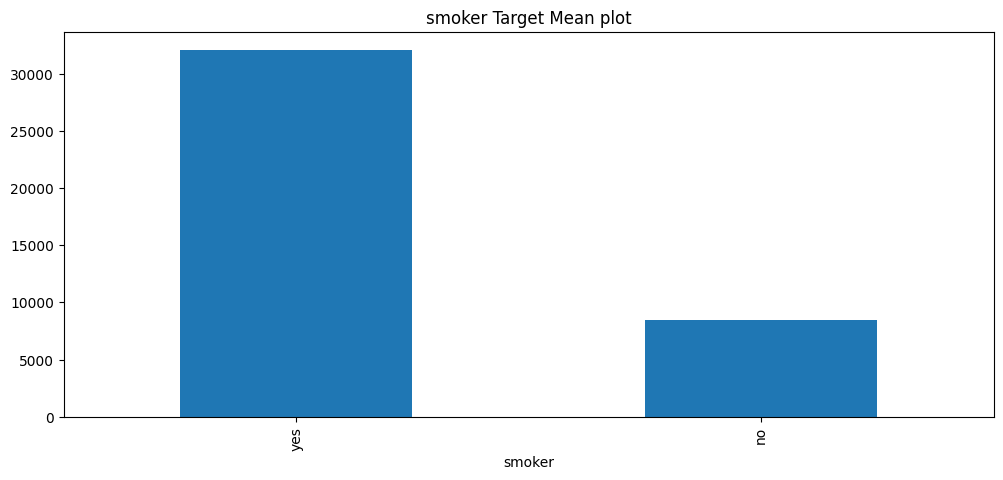

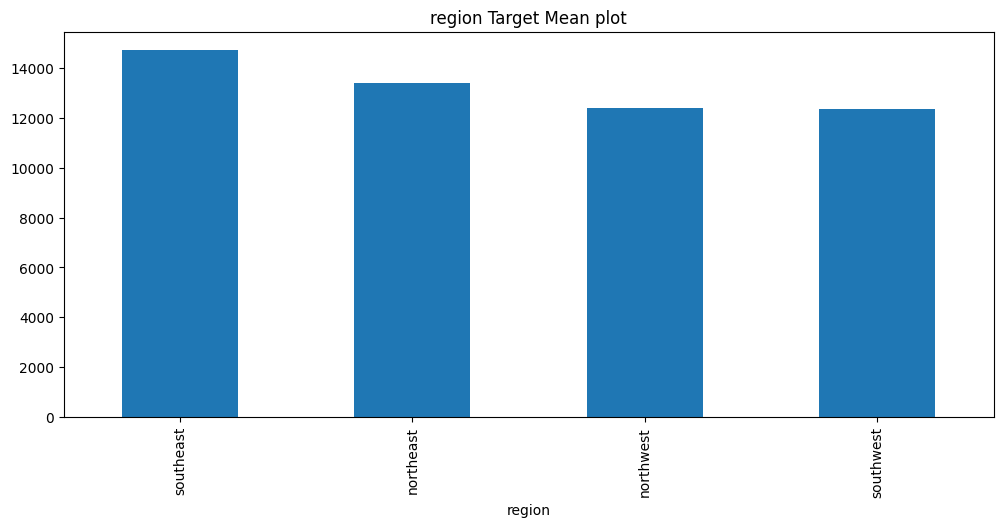

In [60]:
for col in cat_cols:
    target_mean = df.groupby(col)['charges'].mean().sort_values(ascending=False)
    plt.figure(figsize=(12, 5))
    target_mean.plot(kind='bar')
    plt.title(f"{col} Target Mean plot")
    plt.show()

### Statistical Tests 

In [62]:
from scipy.stats import f_oneway, ttest_ind

results = {}

for col in cat_cols:
    unique_vals = df[col].dropna().unique()

    if len(unique_vals) ==2:
        group1 = df[df[col] == unique_vals[0]]['charges']
        group2 = df[df[col] == unique_vals[1]]['charges']
        stat, p_val = ttest_ind(group1, group2)
        test_type = 'ttest'
    else:
        groups = [df[df[col] == val]['charges']for val in unique_vals]
        stats, p_val = f_oneway(*groups)    
        test_type = 'ANOVA'

    results[col] = {'Test': test_type, 'Stats':stats, 'p-values':p_val}

results_df = pd.DataFrame(results).T.sort_values('p-values')
print(results_df)

         Test     Stats  p-values
smoker  ttest  2.969627       0.0
region  ANOVA  2.969627  0.030893
sex     ttest  2.969627  0.036133


### Correlation and Multicollinearity 

In [67]:
df[num_cols].corr(method = 'spearman')

,age,bmi,children,charges
age,1.000000,0.107736,0.056992,0.534392
bmi,0.107736,1.000000,0.015607,0.119396
children,0.056992,0.015607,1.000000,0.133339
charges,0.534392,0.119396,0.133339,1.000000


In [68]:
df[num_cols].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

X_vif  = df[num_cols].drop('charges', axis = 1)

vif_df = pd.DataFrame({
    'feature': X_vif .columns ,
    'vif':[vif(X_vif .values, i) for i in range(X_vif .shape[1])]
})

print(vif_df)

    feature       vif
0       age  7.536550
1       bmi  7.846515
2  children  1.796637
